# HOTWORX Churn Demo - Phase 1: Synthetic Population Visualization

This notebook loads the generated synthetic tables and visualizes key properties of the simulated population, demonstrating:
1. **Seasonality**: January signup spikes and summer activity dips.
2. **Session booking heatmaps**: Peak times and workout distributions.
3. **Churn timelines**: Active members over time across the three cohorts (`steady`, `declining`, `sudden_drop`).
4. **Correlated signals**: The 14-day gap between billing failure and account cancellation.

### Security Header Check
All synthetic Parquet files are marked with a custom metadata tag `SYNTHETIC_DATA: TRUE` and include an `is_synthetic` column.

In [1]:
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq

# Set aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = "./data"
print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data & Verify Security Metadata

In [2]:
# Load files
studios = pd.read_parquet(os.path.join(DATA_DIR, "studios.parquet"))
members = pd.read_parquet(os.path.join(DATA_DIR, "members.parquet"))
memberships = pd.read_parquet(os.path.join(DATA_DIR, "memberships.parquet"))
sessions = pd.read_parquet(os.path.join(DATA_DIR, "sessions.parquet"))
transactions = pd.read_parquet(os.path.join(DATA_DIR, "transactions.parquet"))
ground_truth = pd.read_parquet(os.path.join(DATA_DIR, "ground_truth.parquet"))

# Print Shapes
print(f"Studios Shape: {studios.shape}")
print(f"Members Shape: {members.shape}")
print(f"Memberships Shape: {memberships.shape}")
print(f"Sessions Shape: {sessions.shape}")
print(f"Transactions Shape: {transactions.shape}")
print(f"Ground Truth Shape: {ground_truth.shape}")

# Verify Metadata Security Header
print("\n--- Parquet Metadata Security Header Check ---")
for filename in ["studios", "members", "memberships", "sessions", "transactions", "ground_truth"]:
    filepath = os.path.join(DATA_DIR, f"{filename}.parquet")
    meta = pq.read_metadata(filepath)
    is_synthetic_val = meta.metadata.get(b"SYNTHETIC_DATA", b"NONE").decode('utf-8')
    print(f"{filename}.parquet metadata 'SYNTHETIC_DATA' = {is_synthetic_val}")

Studios Shape: (10, 7)
Members Shape: (5000, 9)
Memberships Shape: (5000, 9)
Sessions Shape: (986850, 8)
Transactions Shape: (111481, 8)
Ground Truth Shape: (5000, 6)

--- Parquet Metadata Security Header Check ---
studios.parquet metadata 'SYNTHETIC_DATA' = TRUE
members.parquet metadata 'SYNTHETIC_DATA' = TRUE
memberships.parquet metadata 'SYNTHETIC_DATA' = TRUE
sessions.parquet metadata 'SYNTHETIC_DATA' = TRUE
transactions.parquet metadata 'SYNTHETIC_DATA' = TRUE
ground_truth.parquet metadata 'SYNTHETIC_DATA' = TRUE


## 2. Member Signup Seasonality

Let's visualize when members join the studio. We expect to see a massive spike in January (New Year's resolutions) and a significant dip during the hot summer months (June, July, August).

/var/folders/pt/wmxj_98525gfgmgpb2lz5_xw0000gn/T/ipykernel_84341/3757980981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_signups, x='join_month_str', y='signups', palette='Oranges_r')


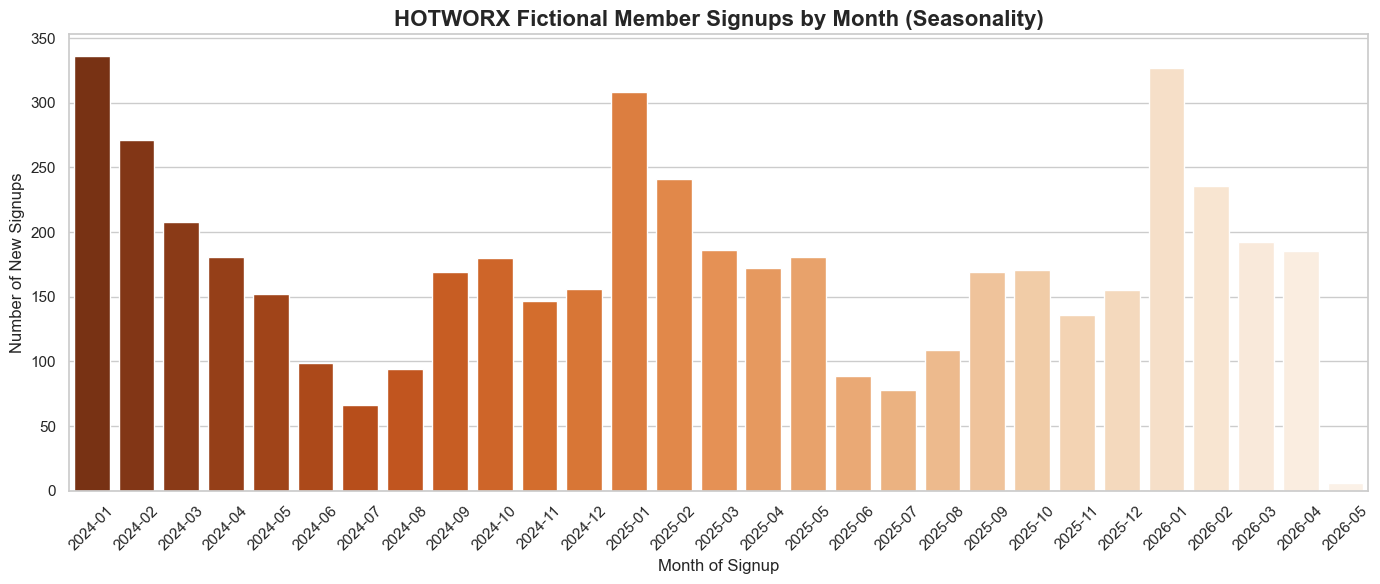

In [3]:
# Convert join_date to datetime to easily group by month
members['join_date_dt'] = pd.to_datetime(members['join_date'])
members['join_month'] = members['join_date_dt'].dt.to_period('M')
monthly_signups = members.groupby('join_month').size().reset_index(name='signups')
monthly_signups['join_month_str'] = monthly_signups['join_month'].astype(str)

plt.figure(figsize=(14, 6))
sns.barplot(data=monthly_signups, x='join_month_str', y='signups', palette='Oranges_r')
plt.title("HOTWORX Fictional Member Signups by Month (Seasonality)", fontsize=16, fontweight='bold')
plt.xlabel("Month of Signup", fontsize=12)
plt.ylabel("Number of New Signups", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("signup_seasonality.png", dpi=300)
plt.show()

## 3. Booking Heatmaps (Day of Week vs. Hour of Day)

HOTWORX provides 24-hour access to infrared saunas. We visualize when bookings are scheduled to identify peak operational hours and see if workout bookings follow typical gym rush hours (morning and evening).

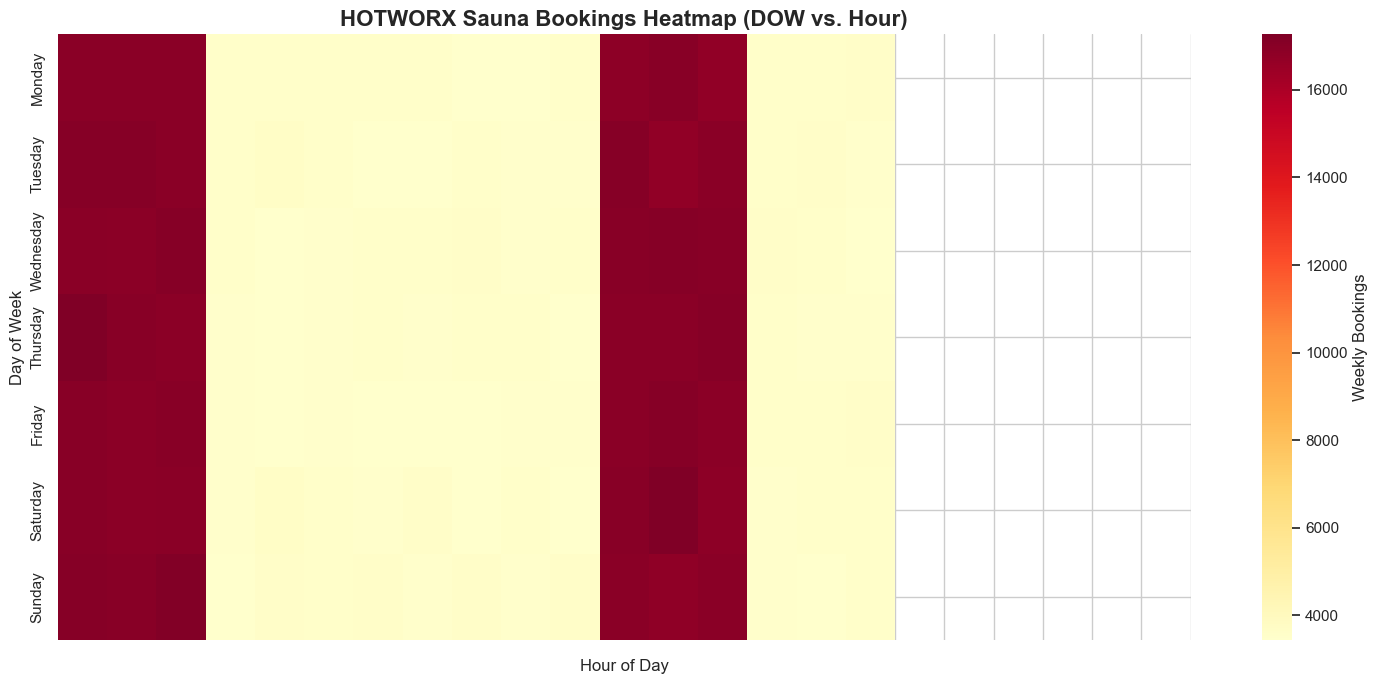

In [4]:
sessions['scheduled_at_dt'] = pd.to_datetime(sessions['scheduled_at'])
sessions['hour'] = sessions['scheduled_at_dt'].dt.hour
sessions['day_of_week'] = sessions['scheduled_at_dt'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create pivot table
heatmap_data = sessions.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(15, 7))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Weekly Bookings'})
plt.title("HOTWORX Sauna Bookings Heatmap (DOW vs. Hour)", fontsize=16, fontweight='bold')
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Day of Week", fontsize=12)
plt.xticks(range(24))
plt.tight_layout()
plt.savefig("booking_heatmap.png", dpi=300)
plt.show()

## 4. Churn Timeline & Active Count per Cohort

This visualization demonstrates the population timeline from Jan 2024 to Jun 2026. We check the active member counts for each of our simulated behavioral segments:
- **Steady (70%)**: Consistent, healthy growth with negligible churn.
- **Declining (20%)**: Slow, linear decay in active count as members gradually stop scheduling sessions and cancel.
- **Sudden Dropper (10%)**: Sudden cancellation curves triggered by payment failures.

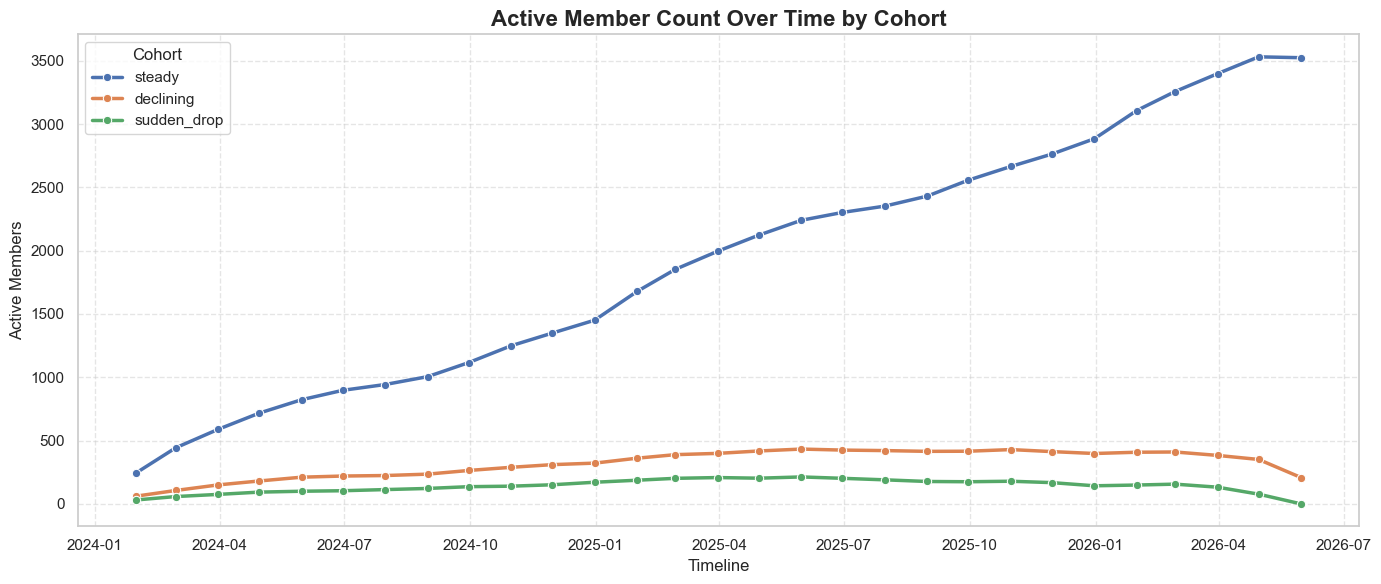

In [5]:
# Merge members with ground truth details
member_profiles = members.merge(ground_truth, on='member_id')

# Construct a monthly active member timeline
months = pd.date_range(start='2024-01-01', end='2026-06-01', freq='ME')
timeline_records = []

for m in months:
    m_date = m.date()
    for cohort in ['steady', 'declining', 'sudden_drop']:
        cohort_members = member_profiles[member_profiles['cohort'] == cohort]
        # Active if they joined on/before this month AND (have not churned OR churned after this month)
        active = cohort_members[
            (cohort_members['join_date'] <= m_date) &
            ((cohort_members['churned'] == False) | (cohort_members['churn_date'] > m_date))
        ]
        timeline_records.append({
            'Month': m,
            'Cohort': cohort,
            'Active Members': len(active)
        })

timeline_df = pd.DataFrame(timeline_records)

plt.figure(figsize=(14, 6))
sns.lineplot(data=timeline_df, x='Month', y='Active Members', hue='Cohort', marker='o', linewidth=2.5)
plt.title("Active Member Count Over Time by Cohort", fontsize=16, fontweight='bold')
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Active Members", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("cohort_timeline.png", dpi=300)
plt.show()

## 5. Correlated Signals: Billing Failure to Cancellation Delta

For our **Sudden Dropper** cohort, billing failure is directly correlated with cancellation. A payment fails, and exactly 14 days later, the membership is auto-cancelled. Let's isolate this delta to prove the pipeline has successfully baked in this signal.

Number of sudden drop billing-to-cancellation records: 482
Mean Days to Cancellation: 14.0 days
Std Dev of Days to Cancellation: 0.0000 days


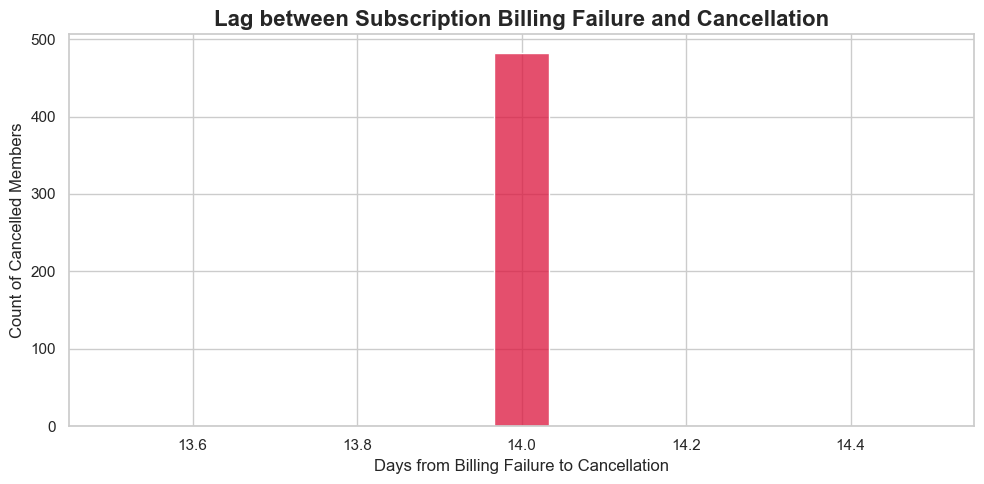

In [6]:
# Isolate sudden droppers who cancelled
sd_members = member_profiles[(member_profiles['cohort'] == 'sudden_drop') & (member_profiles['churned'] == True)]
sd_member_ids = sd_members['member_id'].tolist()

# Find failed subscription invoices for these members
failed_invoices = transactions[
    (transactions['member_id'].isin(sd_member_ids)) &
    (transactions['transaction_type'] == 'Membership Fee') &
    (transactions['status'] == 'Failed')
]

# Merge with churn dates to calculate delta
delta_df = failed_invoices.merge(sd_members[['member_id', 'churn_date']], on='member_id')
delta_df['transaction_date_dt'] = pd.to_datetime(delta_df['transaction_date'])
delta_df['churn_date_dt'] = pd.to_datetime(delta_df['churn_date'])
delta_df['days_to_churn'] = (delta_df['churn_date_dt'] - delta_df['transaction_date_dt']).dt.days

print(f"Number of sudden drop billing-to-cancellation records: {len(delta_df)}")
print(f"Mean Days to Cancellation: {delta_df['days_to_churn'].mean():.1f} days")
print(f"Std Dev of Days to Cancellation: {delta_df['days_to_churn'].std():.4f} days")

plt.figure(figsize=(10, 5))
sns.histplot(delta_df['days_to_churn'], bins=15, kde=False, color='crimson')
plt.title("Lag between Subscription Billing Failure and Cancellation", fontsize=16, fontweight='bold')
plt.xlabel("Days from Billing Failure to Cancellation", fontsize=12)
plt.ylabel("Count of Cancelled Members", fontsize=12)
plt.tight_layout()
plt.savefig("billing_failure_delta.png", dpi=300)
plt.show()

## 6. Workout Attendance Decline (Decline Cohort)

Let's see if the attendance drop-off matches our gradually declining cohort design. For each member in the declining cohort, we expect their session attendance rate (Attended / Scheduled) to fall linearly as they approach cancellation.

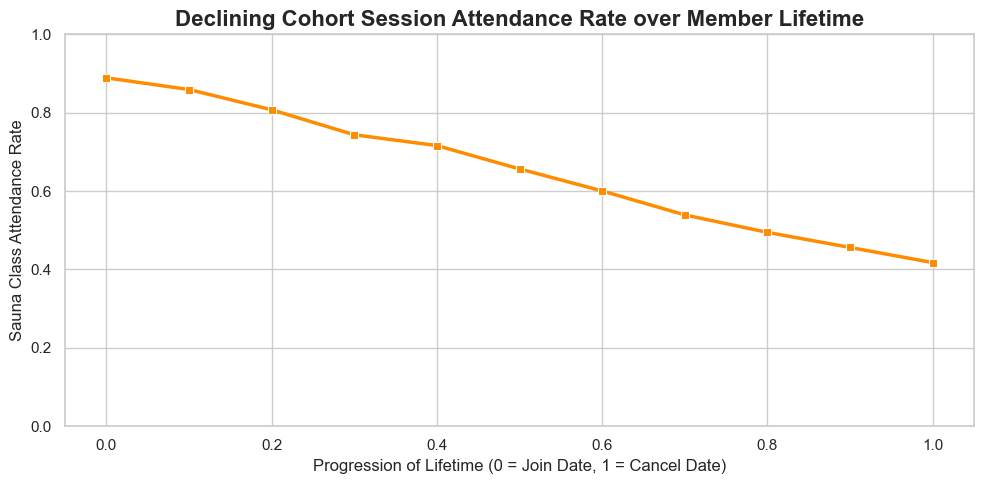

In [7]:
# Analyze weekly attendance trend for declining cohort
declining_members = member_profiles[(member_profiles['cohort'] == 'declining') & (member_profiles['churned'] == True)]
dec_member_ids = declining_members['member_id'].tolist()

# Grab sessions for these members
dec_sessions = sessions[sessions['member_id'].isin(dec_member_ids)].copy()

# Merge member join_date and churn_date
dec_sessions = dec_sessions.merge(declining_members[['member_id', 'join_date', 'churn_date']], on='member_id')
dec_sessions['join_date_dt'] = pd.to_datetime(dec_sessions['join_date'])
dec_sessions['churn_date_dt'] = pd.to_datetime(dec_sessions['churn_date'])

# Calculate when the session happened relative to their lifetime (from 0 to 1)
dec_sessions['lifetime_days'] = (dec_sessions['churn_date_dt'] - dec_sessions['join_date_dt']).dt.days
dec_sessions['session_day'] = (dec_sessions['scheduled_at_dt'] - dec_sessions['join_date_dt']).dt.days
dec_sessions['lifetime_progress'] = dec_sessions['session_day'] / dec_sessions['lifetime_days']

# Bin progress into deciles
dec_sessions['progress_bin'] = (dec_sessions['lifetime_progress'] * 10).round() / 10
dec_sessions['progress_bin'] = dec_sessions['progress_bin'].clip(0, 1)

# Calculate attendance rate per progress bin
att_rate = dec_sessions.groupby('progress_bin')['attended'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=att_rate, x='progress_bin', y='attended', marker='s', color='darkorange', linewidth=2.5)
plt.title("Declining Cohort Session Attendance Rate over Member Lifetime", fontsize=16, fontweight='bold')
plt.xlabel("Progression of Lifetime (0 = Join Date, 1 = Cancel Date)", fontsize=12)
plt.ylabel("Sauna Class Attendance Rate", fontsize=12)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig("decline_attendance.png", dpi=300)
plt.show()